## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Step 2: Load Dataset



In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")  # path change if needed

print(df.head())
print(df.columns)

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:32      Electronics             12         3   
1        46251  2022-03-05 12:56:35             Home            468         4   
2        46251  2022-05-23 18:18:01             Home            288         2   
3        46251  2020-11-12 13:13:29         Clothing            196         1   
4        13593  2020-11-27 17:55:11             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Age  Gender  Churn  
0  Christine Hernandez   37    Male      0  
1  Christine Hernandez   3

## Step 3: Data Cleaning

In [3]:
# Remove spaces from column names
df.columns = df.columns.str.replace(" ", "_")

# Convert date
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Remove duplicates & missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 202404 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer_ID            202404 non-null  int64         
 1   Purchase_Date          202404 non-null  datetime64[ns]
 2   Product_Category       202404 non-null  object        
 3   Product_Price          202404 non-null  int64         
 4   Quantity               202404 non-null  int64         
 5   Total_Purchase_Amount  202404 non-null  int64         
 6   Payment_Method         202404 non-null  object        
 7   Customer_Age           202404 non-null  int64         
 8   Returns                202404 non-null  float64       
 9   Customer_Name          202404 non-null  object        
 10  Age                    202404 non-null  int64         
 11  Gender                 202404 non-null  object        
 12  Churn                  202404 non-null  int64    

## Step 4: Feature Engineering (RFM)

In [4]:
today = df['Purchase_Date'].max()

rfm = df.groupby('Customer_ID').agg({
    'Purchase_Date': lambda x: (today - x.max()).days,
    'Customer_ID': 'count',
    'Total_Purchase_Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

print(rfm.head())

   Customer_ID  Recency  Frequency  Monetary
0            1       57          1      3491
1            2      298          2      7029
2            3       88          7     18172
3            4      585          1      3154
4            5      170          6     10239


## Step 5: RFM Scoring

In [5]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].astype(str).sum(axis=1)

## Step 6: Clustering (Customer Segmentation)

In [8]:
# Create Cluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [9]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_profile)

            Recency  Frequency      Monetary
Cluster                                     
0        220.750510   2.709478   6733.970362
1        155.475160   7.296649  21289.003781
2        796.187857   2.313250   6119.750379
3        212.523495   4.826499  13190.814244


## Step 7: Segment Profiling

In [10]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_profile)

            Recency  Frequency      Monetary
Cluster                                     
0        220.750510   2.709478   6733.970362
1        155.475160   7.296649  21289.003781
2        796.187857   2.313250   6119.750379
3        212.523495   4.826499  13190.814244


## Step 8: Visualizations

## 1. Customer Segments

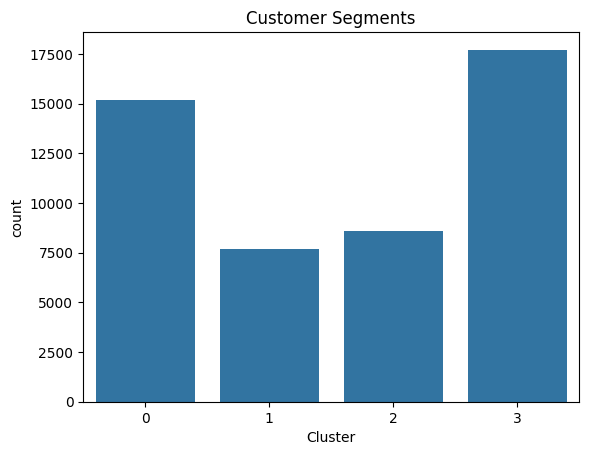

In [11]:
sns.countplot(x='Cluster', data=rfm)
plt.title("Customer Segments")
plt.show()

## 2 Monthly purchase trend

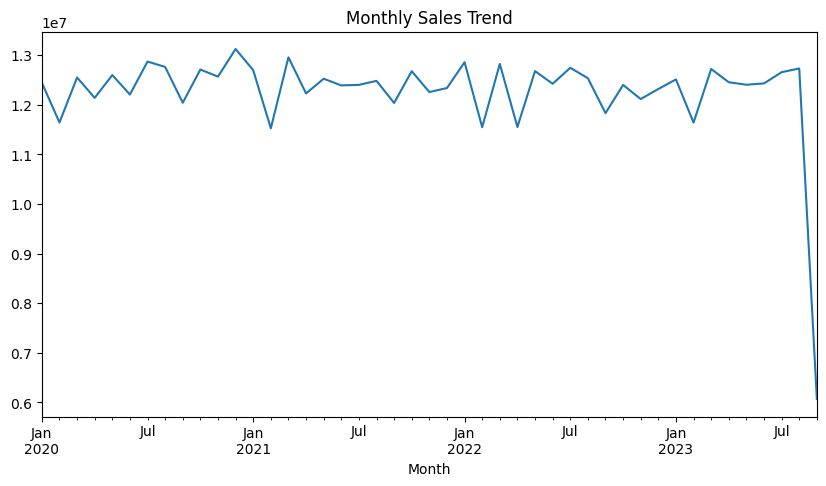

In [12]:
df['Month'] = df['Purchase_Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total_Purchase_Amount'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

## 3. Product Category Analysis

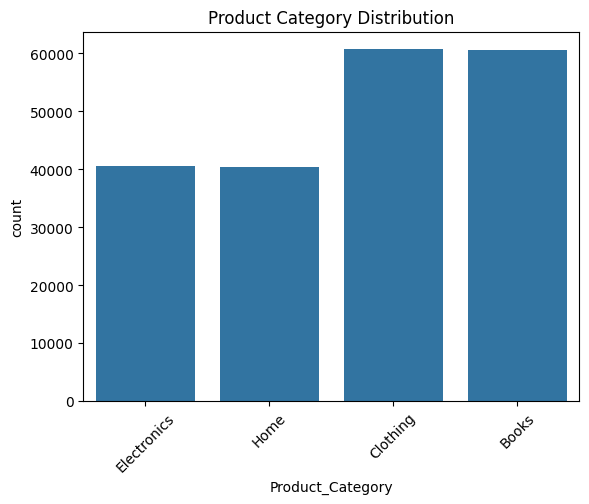

In [13]:
sns.countplot(x='Product_Category', data=df)
plt.xticks(rotation=45)
plt.title("Product Category Distribution")
plt.show()

## 4 Top Customers

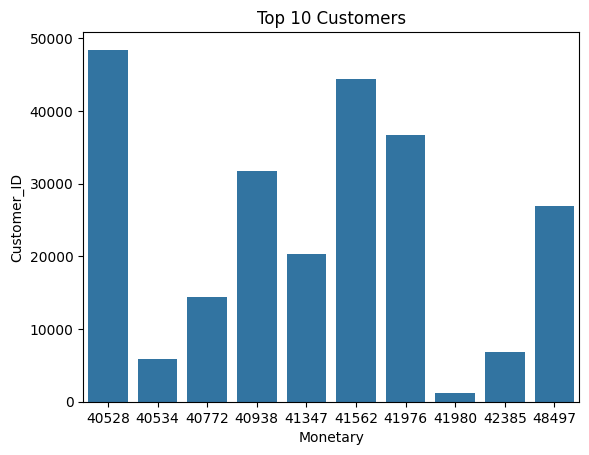

In [14]:
top_customers = rfm.sort_values(by='Monetary', ascending=False).head(10)

sns.barplot(x='Monetary', y='Customer_ID', data=top_customers)
plt.title("Top 10 Customers")
plt.show()

 ## Step 9: Retention & Churn Analysis

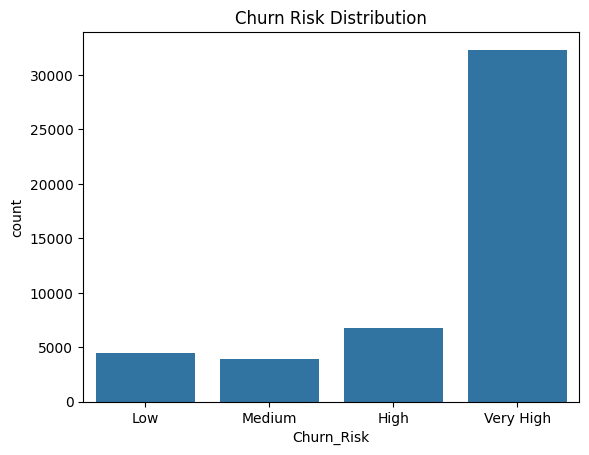

In [15]:
rfm['Churn_Risk'] = pd.cut(rfm['Recency'],
                          bins=[-1,30,60,120,999],
                          labels=['Low','Medium','High','Very High'])

sns.countplot(x='Churn_Risk', data=rfm)
plt.title("Churn Risk Distribution")
plt.show()

## Step 10: Save Output

In [16]:
rfm.to_csv("final_rfm_output.csv", index=False)